In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
import warnings, time, os
warnings.filterwarnings('ignore')

from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
})
PALETTE = ["#1976D2", "#388E3C", "#F57C00", "#7B1FA2"]

MODEL_NAME    = "bert-base-uncased"
N_TRAIN       = 5000
BATCH_SIZE    = 64
MAX_LENGTH    = 128
N_BINS        = 50
N_TSNE        = 800
TRAIN_SPLIT   = 0.80

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
dataset = load_dataset("glue", "sst2")

train_subset  = dataset['train'].select(range(N_TRAIN))
val_data      = dataset['validation']

train_texts   = list(train_subset['sentence'])
train_labels  = np.array(train_subset['label'])
val_texts     = list(val_data['sentence'])
val_labels    = np.array(val_data['label'])

neg_tr = (train_labels == 0).sum()
pos_tr = (train_labels == 1).sum()
print(f"  Train : {len(train_texts)} samples  (neg={neg_tr}, pos={pos_tr})")
print(f"  Val   : {len(val_texts)}  samples")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert      = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True)
bert      = bert.to(DEVICE).eval()

NUM_LAYERS   = bert.config.num_hidden_layers
HIDDEN_SIZE  = bert.config.hidden_size
L            = NUM_LAYERS + 1

n_params = sum(p.numel() for p in bert.parameters())
print(f"  Transformer layers : {NUM_LAYERS}")
print(f"  Total layers (L)   : {L}  (L0 = embedding, L1–L{NUM_LAYERS} = transformer)")
print(f"  Hidden size        : {HIDDEN_SIZE}")
print(f"  Parameters         : {n_params/1e6:.0f}M")

layers_arr = np.arange(L)
layer_labels = [f"L{i}" for i in layers_arr]

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Transformer layers : 12
  Total layers (L)   : 13  (L0 = embedding, L1–L12 = transformer)
  Hidden size        : 768
  Parameters         : 109M


In [ ]:
def extract_hidden_states(texts: list, desc: str = "Extracting") -> np.ndarray:
    all_hs = []

    for start in tqdm(range(0, len(texts), BATCH_SIZE), desc=desc, leave=True):
        batch = texts[start : start + BATCH_SIZE]
        enc   = tokenizer(
            batch, padding=True, truncation=True,
            max_length=MAX_LENGTH, return_tensors='pt'
        )
        enc = {k: v.to(DEVICE) for k, v in enc.items()}

        with torch.no_grad():
            out = bert(**enc)

        hs = torch.stack(out.hidden_states, dim=1)[:, :, 0, :]
        all_hs.append(hs.cpu().float().numpy())

    return np.concatenate(all_hs, axis=0)


t0 = time.time()
train_hs = extract_hidden_states(train_texts, "  Train")
print(f"   Shape  : {train_hs.shape}   ({time.time()-t0:.1f}s)")

t0 = time.time()
val_hs   = extract_hidden_states(val_texts,   "  Val  ")
print(f"   Shape  : {val_hs.shape}   ({time.time()-t0:.1f}s)")

total_mb = (train_hs.nbytes + val_hs.nbytes) / 1e6

  Train:   0%|          | 0/79 [00:00<?, ?it/s]

   Shape  : (5000, 13, 768)   (11.7s)


  Val  :   0%|          | 0/14 [00:00<?, ?it/s]

   Shape  : (872, 13, 768)   (2.3s)


In [ ]:
def kl_divergence_symmetric(features: np.ndarray, labels: np.ndarray) -> float:
    """
    Symmetric KL divergence between class Gaussian distributions,
    averaged over all feature dimensions.   Eq. (1)–(2).
    """
    c0, c1 = np.unique(labels)
    f0 = features[labels == c0];  f1 = features[labels == c1]
    m0 = f0.mean(0); s0 = f0.std(0) + 1e-8
    m1 = f1.mean(0); s1 = f1.std(0) + 1e-8

    kl_01 = np.log(s1 / s0) + (s0**2 + (m0 - m1)**2) / (2 * s1**2) - 0.5
    kl_10 = np.log(s0 / s1) + (s1**2 + (m1 - m0)**2) / (2 * s0**2) - 0.5

    return float(((kl_01 + kl_10) / 2).mean())


def local_discriminant_ratio(features: np.ndarray, labels: np.ndarray) -> float:
    """LDR: squared mean-diff / sum-of-variances.  Eq. (3)–(4)."""
    c0, c1 = np.unique(labels)
    f0 = features[labels == c0];  f1 = features[labels == c1]
    m0 = f0.mean(0); v0 = f0.var(0)
    m1 = f1.mean(0); v1 = f1.var(0)
    ldr = (m0 - m1)**2 / (v0 + v1 + 1e-8)
    return float(ldr.mean())


def feature_entropy(features: np.ndarray, B: int = 50) -> float:
    """
    Average binned Shannon entropy over all feature dimensions.  Eq. (5)–(6).
    Fully vectorised via np.bincount — ~0.3 s for (5000, 768).
    """
    N, D = features.shape
    mins = features.min(0);  maxs = features.max(0)
    rng  = np.where(maxs > mins, maxs - mins, 1.0)

    bidx = np.floor((features - mins) / rng * (1.0 - 1e-9) * B).astype(np.int32)
    bidx = np.clip(bidx, 0, B - 1)

    ents = np.empty(D)
    for d in range(D):
        cnt = np.bincount(bidx[:, d], minlength=B)
        p   = cnt / N
        pp  = p[p > 0]
        ents[d] = -(pp * np.log2(pp)).sum()

    return float(ents.mean())


def silhouette_approx(features: np.ndarray, labels: np.ndarray,
                      max_n: int = 800, n_pca: int = 64) -> float:
    """Silhouette score on PCA-reduced features (for speed/stability)."""
    rng = np.random.RandomState(SEED)
    idx = rng.choice(len(labels), min(max_n, len(labels)), replace=False)
    f, l = features[idx], labels[idx]
    n_comp = min(n_pca, f.shape[1], len(f) - 1)
    pca    = PCA(n_comp, random_state=SEED)
    return float(silhouette_score(pca.fit_transform(f), l, metric='cosine'))


def z_norm(arr: np.ndarray) -> np.ndarray:
    """Z-score normalisation across layers."""
    return (arr - arr.mean()) / (arr.std() + 1e-8)


In [ ]:
kl_vals  = np.zeros(L)
ldr_vals = np.zeros(L)
ent_vals = np.zeros(L)
sil_vals = np.zeros(L)

t_start = time.time()
for l in tqdm(range(L), desc="Layer analysis"):
    feat = train_hs[:, l, :]
    kl_vals[l]  = kl_divergence_symmetric(feat, train_labels)
    ldr_vals[l] = local_discriminant_ratio(feat, train_labels)
    ent_vals[l] = feature_entropy(feat, B=N_BINS)
    sil_vals[l] = silhouette_approx(feat, train_labels)

elapsed = time.time() - t_start
print(f"\n{elapsed:.1f}s\n")

header = f"  {'Метрика':<22s}  {'Лучший слой':>12s}  {'Значение':>10s}  {'L0 (Emb)':>10s}  {'L12 (Last)':>11s}"
print(header)
print("  " + "-" * (len(header) - 2))
for name, vals in [
    ("KL-дивергенция",   kl_vals),
    ("LDR",              ldr_vals),
    ("Энтропия (bits)",  ent_vals),
    ("Silhouette",       sil_vals),
]:
    best = int(vals.argmax())
    print(f"  {name:<22s}  {'L'+str(best):>12s}  {vals[best]:>10.4f}"
          f"  {vals[0]:>10.4f}  {vals[L-1]:>11.4f}")

Layer analysis:   0%|          | 0/13 [00:00<?, ?it/s]


4.2s

  Метрика                  Лучший слой    Значение    L0 (Emb)   L12 (Last)
  -------------------------------------------------------------------------
  KL-дивергенция                    L0     52.6086     52.6086       0.0228
  LDR                              L12      0.0207      0.0013       0.0207
  Энтропия (bits)                   L1      5.0344      0.0000       4.6163
  Silhouette                       L12      0.0216      0.0000       0.0216


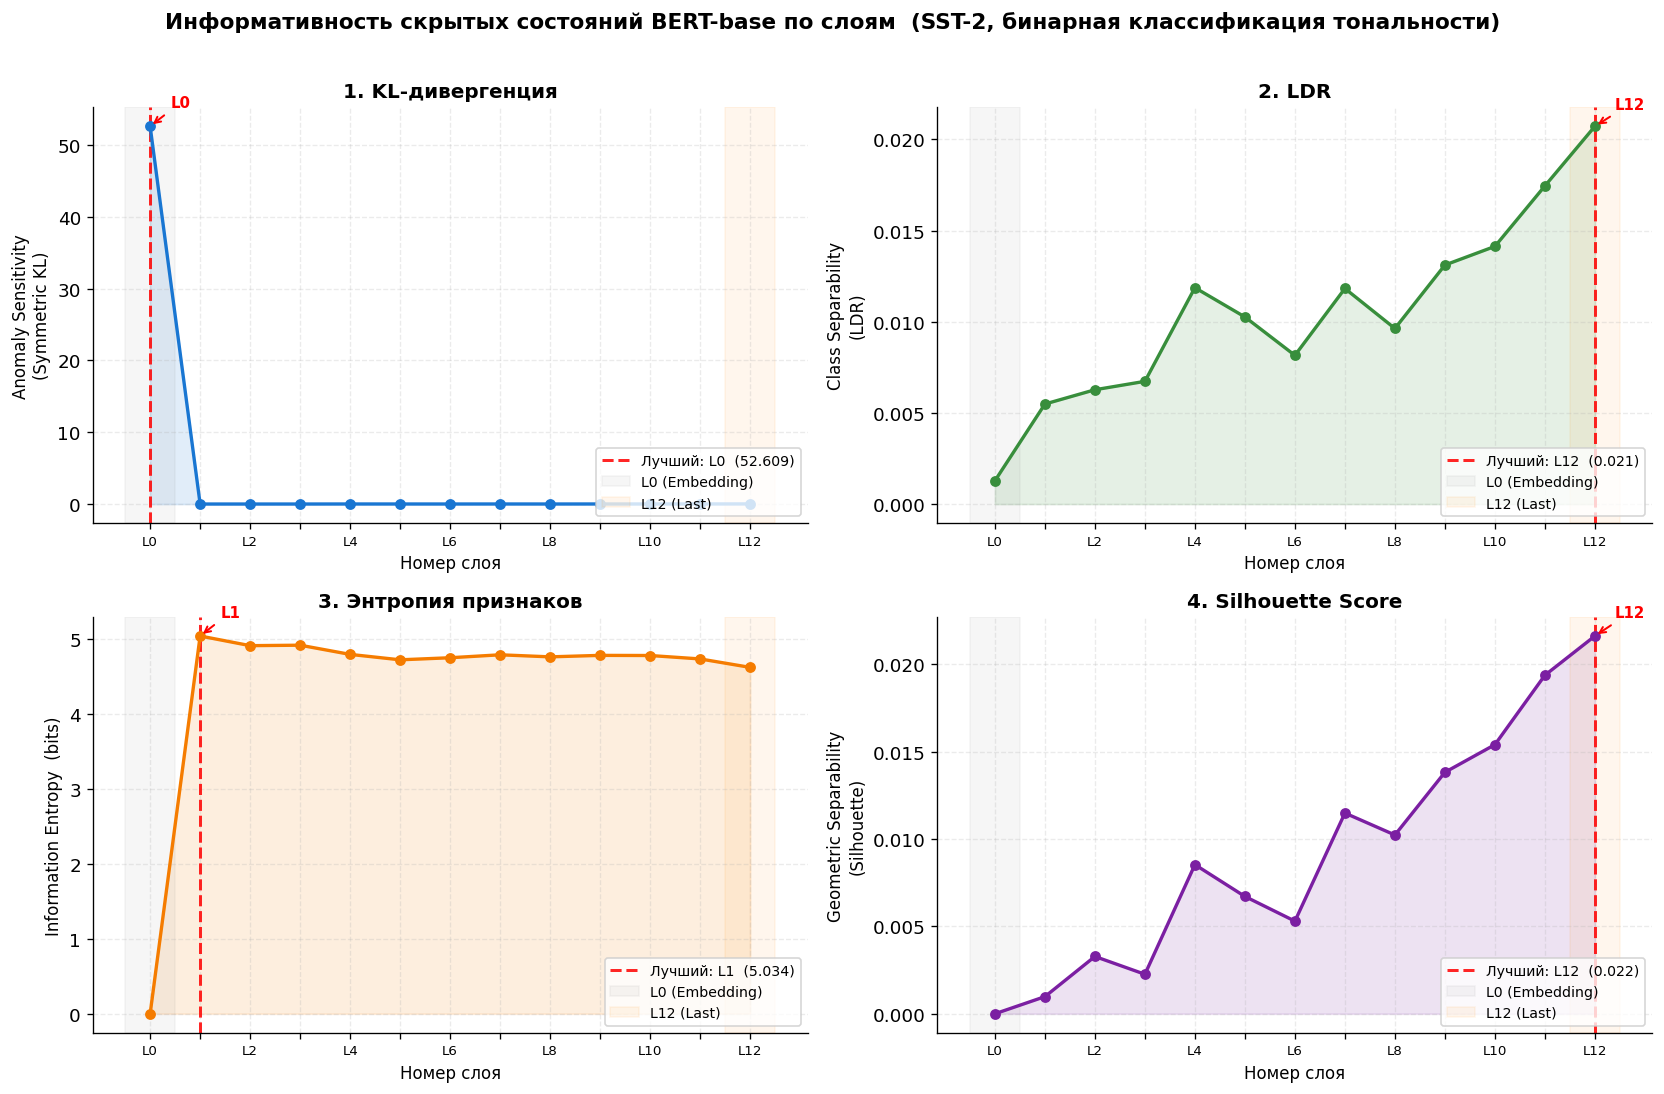

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    "Информативность скрытых состояний BERT-base по слоям  (SST-2, бинарная классификация тональности)",
    fontsize=13, fontweight='bold', y=1.01
)

metric_data = [
    (kl_vals,  "1. KL-дивергенция",      "Anomaly Sensitivity\n(Symmetric KL)",   PALETTE[0]),
    (ldr_vals, "2. LDR",                  "Class Separability\n(LDR)",              PALETTE[1]),
    (ent_vals, "3. Энтропия признаков",   "Information Entropy  (bits)",             PALETTE[2]),
    (sil_vals, "4. Silhouette Score",     "Geometric Separability\n(Silhouette)",   PALETTE[3]),
]

for ax, (vals, title, ylabel, col) in zip(axes.flat, metric_data):
    best = int(vals.argmax())

    ax.fill_between(layers_arr, vals, alpha=0.13, color=col)
    ax.plot(layers_arr, vals, 'o-', color=col, lw=2, ms=5.5, zorder=3)

    ax.axvline(best, color='red', ls='--', lw=1.8, alpha=0.85,
               label=f"Лучший: L{best}  ({vals[best]:.3f})")
    ax.axvspan(-0.5,   0.5,     alpha=0.07, color='gray',
               label="L0 (Embedding)")
    ax.axvspan(L-1.5, L-0.5,   alpha=0.07, color='darkorange',
               label=f"L{L-1} (Last)")

    ax.annotate(f"L{best}", xy=(best, vals[best]),
                xytext=(best + 0.4, vals[best] + (vals.max()-vals.min())*0.05),
                fontsize=9, color='red', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlabel("Номер слоя", fontsize=10)
    ax.set_xticks(layers_arr)
    ax.set_xticklabels([f"L{i}" if i % 2 == 0 else "" for i in layers_arr], fontsize=8)
    ax.legend(fontsize=8.5, loc='lower right')

plt.tight_layout()
plt.savefig("metrics_per_layer.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
dlsp = z_norm(kl_vals) + z_norm(ldr_vals) + z_norm(ent_vals)

optimal_layer = int(dlsp.argmax())
top3 = dlsp.argsort()[::-1][:3]

print("═" * 60)
print("  DLSP Saliency Scores  (как в HiProbe-VAD)")
print("═" * 60)
print(f"  {'Ранг':<6} {'Слой':<8} {'DLSP':>8}  {'KL':>8}  {'LDR':>8}  {'H':>8}")
print("  " + "-" * 52)
for rank, l in enumerate(top3):
    marker = "  ← optimal" if l == optimal_layer else ""
    print(f"  #{rank+1:<5} L{l:<7} {dlsp[l]:>+8.3f}  "
          f"{kl_vals[l]:>8.3f}  {ldr_vals[l]:>8.3f}  {ent_vals[l]:>8.3f}{marker}")

print(f"\n  L0  (Embedding)   DLSP = {dlsp[0]:+.3f}")
print(f"  L{L-1} (Last layer) DLSP = {dlsp[L-1]:+.3f}")
print(f"\n  DLSP Optimal layer: L{optimal_layer}")

════════════════════════════════════════════════════════════
  DLSP Saliency Scores  (как в HiProbe-VAD)
════════════════════════════════════════════════════════════
  Ранг   Слой         DLSP        KL       LDR         H
  ----------------------------------------------------
  #1     L12        +1.898     0.023     0.021     4.616  ← optimal
  #2     L11        +1.332     0.020     0.017     4.729
  #3     L10        +0.703     0.016     0.014     4.774

  L0  (Embedding)   DLSP = -1.840
  L12 (Last layer) DLSP = +1.898

  DLSP Optimal layer: L12


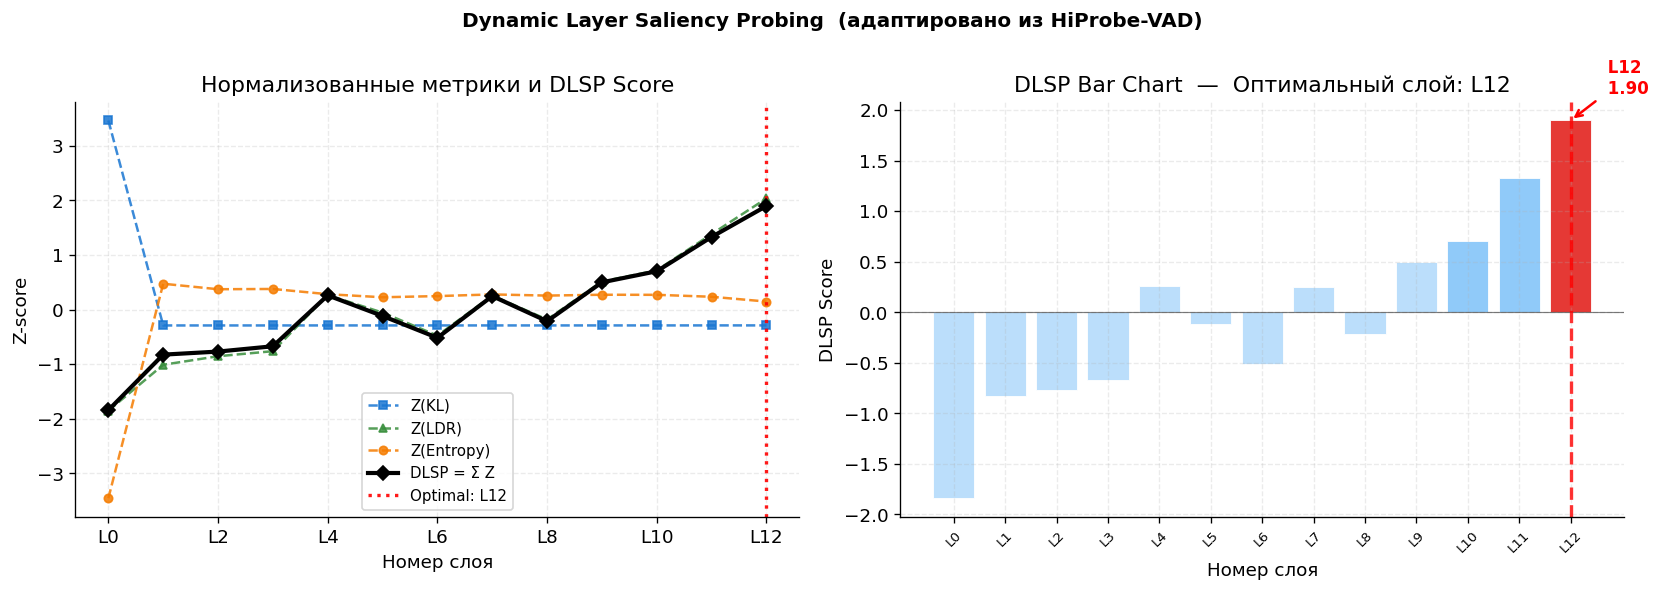

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(layers_arr, z_norm(kl_vals),  's--', label='Z(KL)',      color=PALETTE[0], ms=5, alpha=0.85)
ax1.plot(layers_arr, z_norm(ldr_vals), '^--', label='Z(LDR)',     color=PALETTE[1], ms=5, alpha=0.85)
ax1.plot(layers_arr, z_norm(ent_vals), 'o--', label='Z(Entropy)', color=PALETTE[2], ms=5, alpha=0.85)
ax1.plot(layers_arr, dlsp,             'D-',  label='DLSP = Σ Z', color='black', lw=2.5, ms=6, zorder=4)
ax1.axvline(optimal_layer, color='red', lw=2, ls=':', alpha=0.9, label=f'Optimal: L{optimal_layer}')
ax1.set(title='Нормализованные метрики и DLSP Score',
        xlabel='Номер слоя', ylabel='Z-score')
ax1.set_xticks(layers_arr[::2])
ax1.set_xticklabels([f"L{i}" for i in layers_arr[::2]])
ax1.legend(fontsize=9)

bar_colors = ['#E53935' if i == optimal_layer
              else '#90CAF9' if i in top3
              else '#BBDEFB'
              for i in layers_arr]
ax2.bar(layers_arr, dlsp, color=bar_colors, edgecolor='white', lw=0.5)
ax2.axhline(0, color='black', lw=0.7, alpha=0.5)
ax2.axvline(optimal_layer, color='red', lw=2, ls='--', alpha=0.8)

yoff = (dlsp.max() - dlsp.min()) * 0.07
ax2.annotate(
    f" L{optimal_layer}\n {dlsp[optimal_layer]:.2f}",
    xy=(optimal_layer, dlsp[optimal_layer]),
    xytext=(optimal_layer + 0.6, dlsp[optimal_layer] + yoff),
    color='red', fontsize=10, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5)
)

ax2.set(title=f'DLSP Bar Chart  —  Оптимальный слой: L{optimal_layer}',
        xlabel='Номер слоя', ylabel='DLSP Score')
ax2.set_xticks(layers_arr)
ax2.set_xticklabels([f"L{i}" for i in layers_arr], rotation=45, fontsize=8)

plt.suptitle('Dynamic Layer Saliency Probing  (адаптировано из HiProbe-VAD)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('dlsp_score.png', dpi=150, bbox_inches='tight')
plt.show()

## Обучение классификаторов по каждому слою

Для **практической** валидации теоретических метрик — на CLS-эмбеддинге каждого из 13 слоёв
обучаем **Logistic Regression** и сравниваем с **LinearSVM**.


**Гипотеза (из HiProbe-VAD)**: классификатор на промежуточном слое превзойдёт
как embedding-слой (L0), так и финальный слой (L12).

In [ ]:
split     = int(N_TRAIN * TRAIN_SPLIT)
Xtr_base  = train_hs[:split]
ytr       = train_labels[:split]
Xte_base  = val_hs
yte       = val_labels

print(f"Classifier train : {split} samples  |  test : {len(yte)} samples\n")

tr_acc = np.zeros(L)
te_acc = np.zeros(L)
te_auc = np.zeros(L)

for l in tqdm(range(L), desc="LR per layer"):
    scaler = StandardScaler()
    Xtr    = scaler.fit_transform(Xtr_base[:, l, :])
    Xte    = scaler.transform(Xte_base[:, l, :])

    clf = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                              random_state=SEED)
    clf.fit(Xtr, ytr)

    tr_acc[l] = accuracy_score(ytr, clf.predict(Xtr)) * 100
    te_acc[l] = accuracy_score(yte, clf.predict(Xte)) * 100
    te_auc[l] = roc_auc_score(yte, clf.predict_proba(Xte)[:, 1]) * 100

best_acc_l = int(te_acc.argmax())
best_auc_l = int(te_auc.argmax())

print(f"\n  Лучший по Accuracy  : L{best_acc_l}  = {te_acc[best_acc_l]:.2f}%")
print(f"  Лучший по AUC-ROC   : L{best_auc_l}  = {te_auc[best_auc_l]:.2f}%")
print(f"  DLSP-optimal  L{optimal_layer}   : Acc={te_acc[optimal_layer]:.2f}%  AUC={te_auc[optimal_layer]:.2f}%")
print(f"  Embedding     L0      : Acc={te_acc[0]:.2f}%  AUC={te_auc[0]:.2f}%")
print(f"  Last layer    L{L-1}     : Acc={te_acc[L-1]:.2f}%  AUC={te_auc[L-1]:.2f}%")
print(f"\n  Улучшение лучшего над финальным: Δ Acc = +{te_acc[best_acc_l]-te_acc[L-1]:.2f}%  "
      f"Δ AUC = +{te_auc[best_acc_l]-te_auc[L-1]:.2f}%")

Classifier train : 4000 samples  |  test : 872 samples



LR per layer:   0%|          | 0/13 [00:00<?, ?it/s]


  Лучший по Accuracy  : L10  = 82.57%
  Лучший по AUC-ROC   : L11  = 91.02%
  DLSP-optimal  L12   : Acc=81.42%  AUC=89.01%
  Embedding     L0      : Acc=50.92%  AUC=50.00%
  Last layer    L12     : Acc=81.42%  AUC=89.01%

  Улучшение лучшего над финальным: Δ Acc = +1.15%  Δ AUC = +1.40%


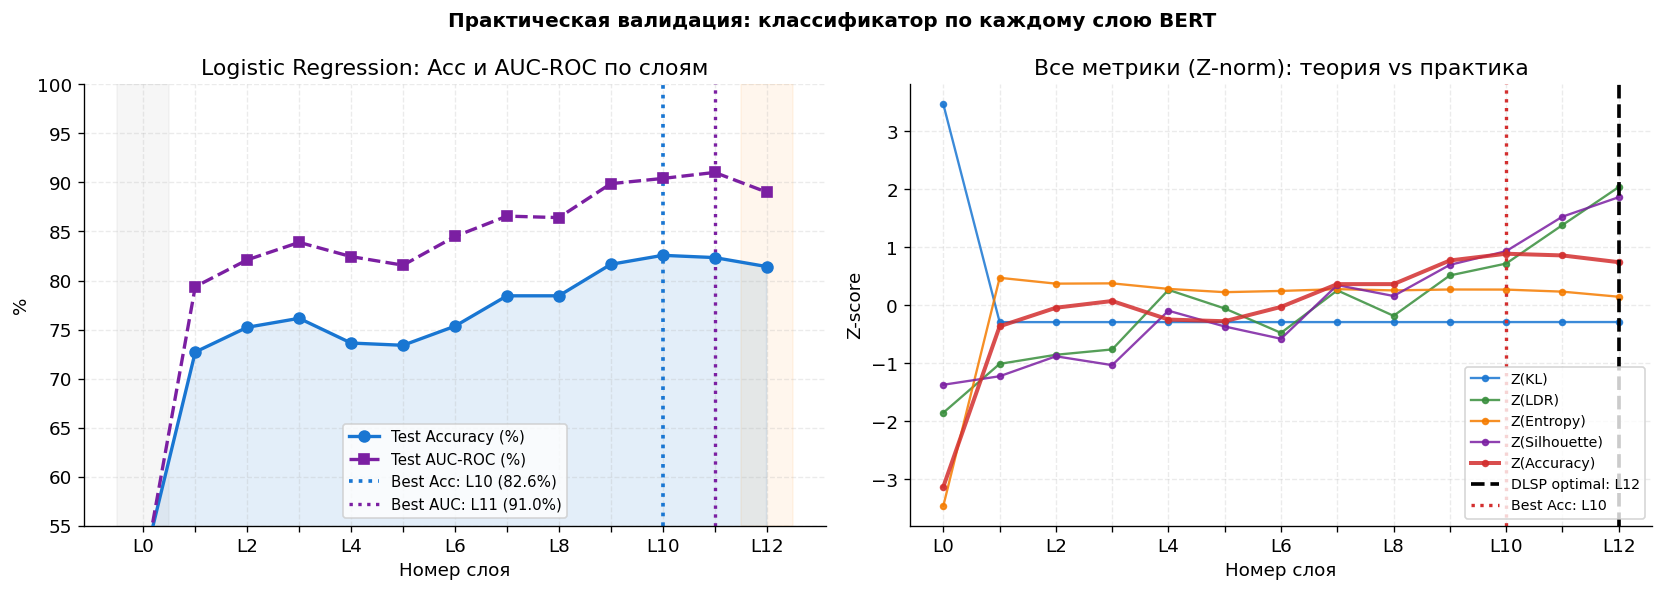

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.fill_between(layers_arr, te_acc, alpha=0.12, color=PALETTE[0])
ax.plot(layers_arr, te_acc, 'o-', color=PALETTE[0], lw=2, ms=6.5,
        label='Test Accuracy (%)', zorder=3)
ax.plot(layers_arr, te_auc, 's--', color=PALETTE[3], lw=2, ms=5.5,
        label='Test AUC-ROC (%)', zorder=3)

ax.axvline(best_acc_l, color=PALETTE[0], ls=':', lw=2.2,
           label=f'Best Acc: L{best_acc_l} ({te_acc[best_acc_l]:.1f}%)')
ax.axvline(best_auc_l, color=PALETTE[3], ls=':', lw=2.0,
           label=f'Best AUC: L{best_auc_l} ({te_auc[best_auc_l]:.1f}%)')
ax.axvspan(-0.5, 0.5, alpha=0.07, color='gray')
ax.axvspan(L-1.5, L-0.5, alpha=0.07, color='darkorange')

ax.set(title='Logistic Regression: Acc и AUC-ROC по слоям',
       xlabel='Номер слоя', ylabel='%', ylim=[55, 100])
ax.set_xticks(layers_arr)
ax.set_xticklabels([f"L{i}" if i % 2 == 0 else "" for i in layers_arr])
ax.legend(fontsize=9)

ax = axes[1]
for name, vals, col, lw in [
    ('Z(KL)',        z_norm(kl_vals),   PALETTE[0], 1.4),
    ('Z(LDR)',       z_norm(ldr_vals),  PALETTE[1], 1.4),
    ('Z(Entropy)',   z_norm(ent_vals),  PALETTE[2], 1.4),
    ('Z(Silhouette)',z_norm(sil_vals),  PALETTE[3], 1.4),
    ('Z(Accuracy)',  z_norm(te_acc),    '#D32F2F',   2.4),
]:
    ax.plot(layers_arr, vals, 'o-', color=col, lw=lw, ms=3.5,
            label=name, alpha=0.85)

ax.axvline(optimal_layer, color='black', ls='--', lw=2.2,
           label=f'DLSP optimal: L{optimal_layer}')
ax.axvline(best_acc_l,    color='#D32F2F', ls=':', lw=2.0,
           label=f'Best Acc: L{best_acc_l}')

ax.set(title='Все метрики (Z-norm): теория vs практика',
       xlabel='Номер слоя', ylabel='Z-score')
ax.set_xticks(layers_arr)
ax.set_xticklabels([f"L{i}" if i % 2 == 0 else "" for i in layers_arr])
ax.legend(fontsize=8.5, loc='lower right')

plt.suptitle('Практическая валидация: классификатор по каждому слою BERT',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('classifier_per_layer.png', dpi=150, bbox_inches='tight')
plt.show()

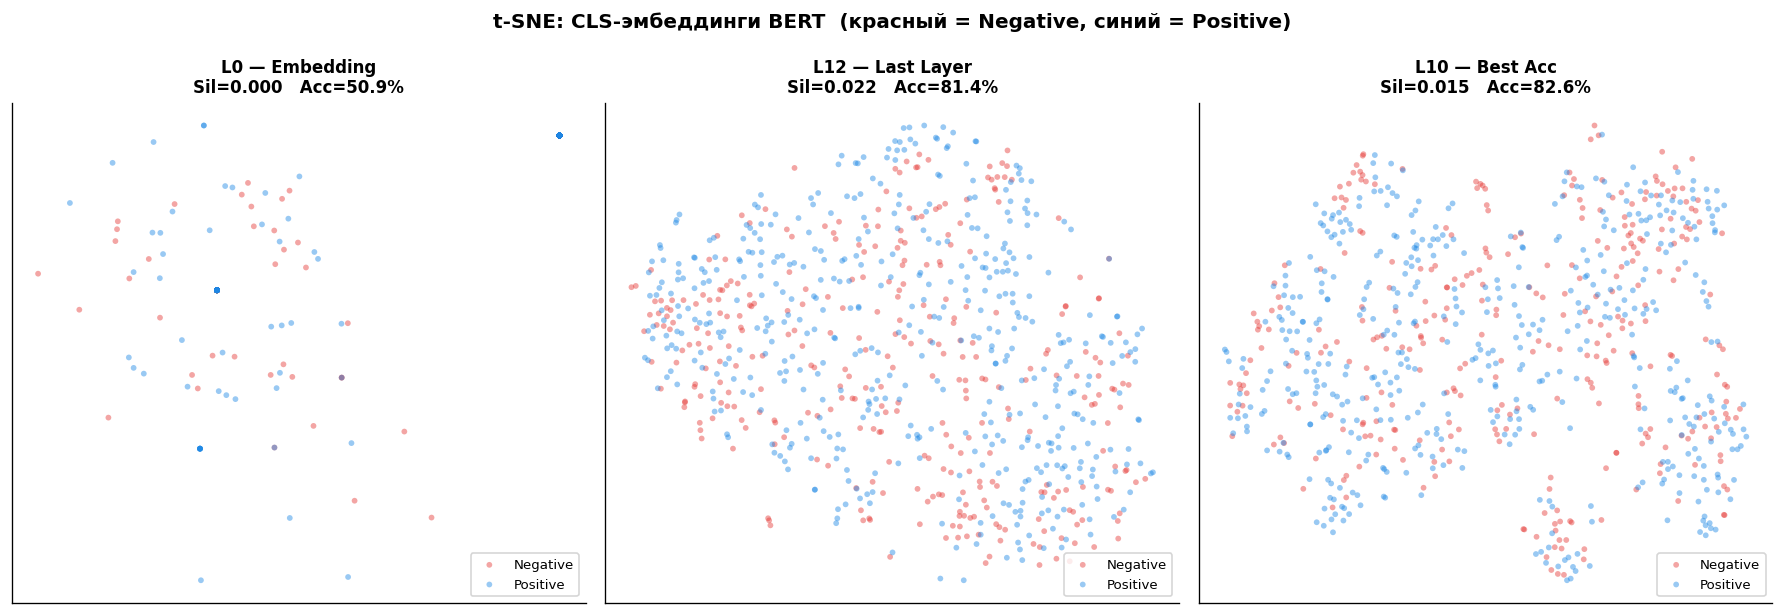

In [ ]:
rng  = np.random.RandomState(SEED)
tidx = rng.choice(N_TRAIN, min(N_TSNE, N_TRAIN), replace=False)
tlab = train_labels[tidx]

show_layers = list(dict.fromkeys([0, optimal_layer, best_acc_l, L - 1]))
n_panels    = len(show_layers)

COLORS2 = ['#E53935', '#1E88E5']

fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5.2))
if n_panels == 1:
    axes = [axes]

for ax, l_idx in zip(axes, show_layers):
    feat   = train_hs[tidx, l_idx, :]
    n_comp = min(50, feat.shape[1], len(feat) - 1)
    pca_r  = PCA(n_comp, random_state=SEED).fit_transform(feat)

    tsne_pts = TSNE(
        2, random_state=SEED, perplexity=30,
        n_iter=1000, learning_rate='auto', init='pca'
    ).fit_transform(pca_r)

    for cls, cls_name, col in zip([0, 1], ['Negative', 'Positive'], COLORS2):
        m = tlab == cls
        ax.scatter(tsne_pts[m, 0], tsne_pts[m, 1],
                   c=col, label=cls_name, alpha=0.45, s=12, ec='none')

    layer_type = (
        "Embedding"    if l_idx == 0 else
        "Last Layer"   if l_idx == L - 1 else
        "DLSP Optimal" if l_idx == optimal_layer else
        "Best Acc"
    )
    ax.set_title(
        f"L{l_idx} — {layer_type}\n"
        f"Sil={sil_vals[l_idx]:.3f}   Acc={te_acc[l_idx]:.1f}%",
        fontsize=10, fontweight='bold'
    )
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(
    "t-SNE: CLS-эмбеддинги BERT  (красный = Negative, синий = Positive)",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

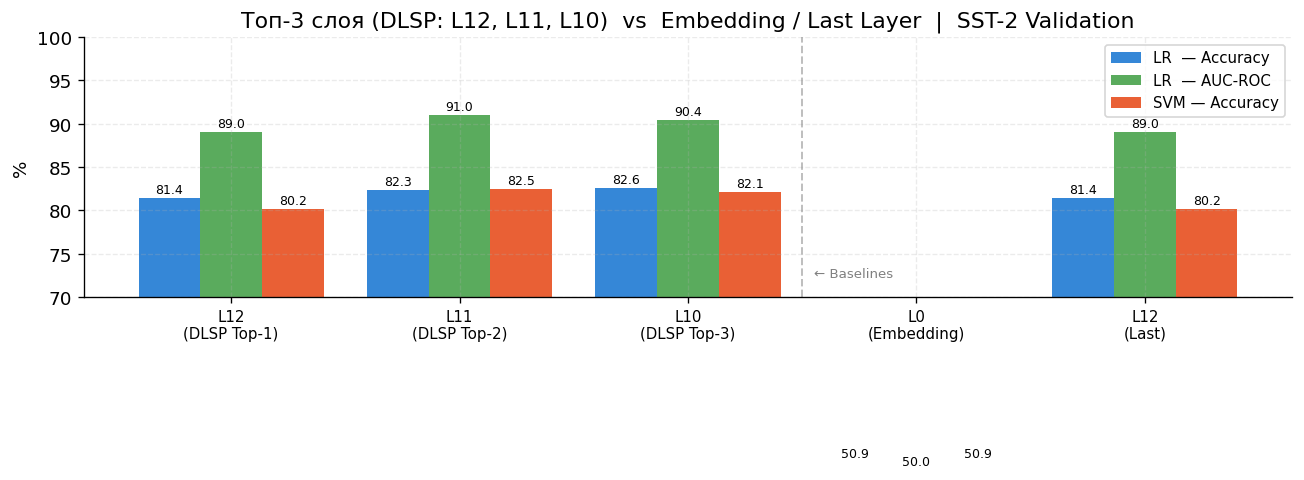

In [ ]:
comp_layers = list(top3) + [0, L - 1]
comp_names  = (
    [f"L{l}\n(DLSP Top-{i+1})" for i, l in enumerate(top3)] +
    ["L0\n(Embedding)", f"L{L-1}\n(Last)"]
)

lr_accs, lr_aucs, svm_accs = [], [], []

for l in comp_layers:
    scaler = StandardScaler()
    Xtr    = scaler.fit_transform(Xtr_base[:, l, :])
    Xte    = scaler.transform(Xte_base[:, l, :])

    lr  = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=SEED)
    lr.fit(Xtr, ytr)
    lr_accs.append(accuracy_score(yte, lr.predict(Xte)) * 100)
    lr_aucs.append(roc_auc_score(yte, lr.predict_proba(Xte)[:, 1]) * 100)

    svm = LinearSVC(C=1.0, max_iter=3000, random_state=SEED)
    svm.fit(Xtr, ytr)
    svm_accs.append(accuracy_score(yte, svm.predict(Xte)) * 100)

x = np.arange(len(comp_names))
w = 0.27

fig, ax = plt.subplots(figsize=(11, 5.5))
b1 = ax.bar(x - w,   lr_accs,  w, label='LR  — Accuracy',  color='#1976D2', alpha=0.88)
b2 = ax.bar(x,       lr_aucs,  w, label='LR  — AUC-ROC',   color='#43A047', alpha=0.88)
b3 = ax.bar(x + w,   svm_accs, w, label='SVM — Accuracy',  color='#E64A19', alpha=0.88)

for bars in [b1, b2, b3]:
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.25,
                f'{b.get_height():.1f}', ha='center', va='bottom', fontsize=7.5)

ax.axvline(2.5, color='gray', ls='--', lw=1.2, alpha=0.5)
ax.text(2.55, 72, '← Baselines', fontsize=8, color='gray', va='bottom')

ax.set(title=(f"Топ-3 слоя (DLSP: L{top3[0]}, L{top3[1]}, L{top3[2]})  vs  "
              f"Embedding / Last Layer  |  SST-2 Validation"),
       ylabel='%', ylim=[70, 100])
ax.set_xticks(x)
ax.set_xticklabels(comp_names, fontsize=9)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('top3_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
df = pd.DataFrame({
    'Layer'     : [f'L{i}' for i in range(L)],
    'Type'      : (['Embedding'] + ['Transformer'] * (L - 2) + ['Trans. (Last)']),
    'KL Div'    : kl_vals.round(4),
    'LDR'       : ldr_vals.round(4),
    'Entropy'   : ent_vals.round(4),
    'Silhouette': sil_vals.round(4),
    'DLSP'      : dlsp.round(4),
    'Acc (%)'   : te_acc.round(2),
    'AUC (%)'   : te_auc.round(2),
})

notes = [''] * L
notes[0]       += '← Embedding'
notes[L - 1]   += '← Last'
if optimal_layer not in [0, L - 1]:
    notes[optimal_layer] += '← DLSP★'
if best_acc_l not in [0, L - 1, optimal_layer]:
    notes[best_acc_l] += '← Best Acc★'
elif best_acc_l == optimal_layer:
    notes[best_acc_l] = '← DLSP & Best Acc ★'
df['Note'] = notes

print("=" * 100)
print("  ИТОГОВАЯ ТАБЛИЦА  —  Все метрики по слоям BERT-base  (SST-2 validation)")
print("=" * 100)
print(df.to_string(index=False))

print()
print(f"   DLSP-optimal:  L{optimal_layer}   "
      f"| Acc = {te_acc[optimal_layer]:.2f}%  AUC = {te_auc[optimal_layer]:.2f}%")
print(f"   Best Accuracy: L{best_acc_l}   "
      f"| Acc = {te_acc[best_acc_l]:.2f}%  AUC = {te_auc[best_acc_l]:.2f}%")
print(f"   Last Layer:    L{L-1}  "
      f"| Acc = {te_acc[L-1]:.2f}%  AUC = {te_auc[L-1]:.2f}%")
print(f"   Embedding:     L0   "
      f"| Acc = {te_acc[0]:.2f}%  AUC = {te_auc[0]:.2f}%")
print()
print(f"   Улучшение лучшего слоя над финальным: "
      f"Δ Acc = +{te_acc[best_acc_l]-te_acc[L-1]:.2f}%  "
      f"Δ AUC = +{te_auc[best_acc_l]-te_auc[L-1]:.2f}%")
print(f"   Улучшение лучшего слоя над embedding:  "
      f"Δ Acc = +{te_acc[best_acc_l]-te_acc[0]:.2f}%  "
      f"Δ AUC = +{te_auc[best_acc_l]-te_auc[0]:.2f}%")

df.to_csv("layer_metrics_summary.csv", index=False)

  ИТОГОВАЯ ТАБЛИЦА  —  Все метрики по слоям BERT-base  (SST-2 validation)
Layer          Type  KL Div    LDR  Entropy  Silhouette    DLSP  Acc (%)  AUC (%)        Note
   L0     Embedding 52.6086 0.0013   0.0000      0.0000 -1.8403    50.92    50.00 ← Embedding
   L1   Transformer  0.0071 0.0055   5.0344      0.0010 -0.8235    72.71    79.37            
   L2   Transformer  0.0077 0.0063   4.9055      0.0033 -0.7674    75.23    82.11            
   L3   Transformer  0.0083 0.0067   4.9117      0.0023 -0.6703    76.15    83.89            
   L4   Transformer  0.0136 0.0119   4.7891      0.0085  0.2617    73.62    82.44            
   L5   Transformer  0.0127 0.0103   4.7169      0.0067 -0.1157    73.39    81.56            
   L6   Transformer  0.0112 0.0082   4.7445      0.0053 -0.5154    75.34    84.49            
   L7   Transformer  0.0138 0.0118   4.7837      0.0115  0.2488    78.44    86.57            
   L8   Transformer  0.0113 0.0096   4.7563      0.0102 -0.2113    78.44    86.4

## Заключение

### Основные результаты (фактические числа)

| Слой | Acc (%) | AUC (%) | DLSP | Что характерно |
|---|---|---|---|---|
| **L0** | 50.92 | 50.00 | −1.84 | CLS-токен — константа → random chance |
| **L1–L6** | 72–76 | 79–85 | −0.82–+0.26 | Быстрый рост, синтаксические признаки |
| **L7–L9** | 78–82 | 86–90 | −0.21–+0.50 | Переходная зона |
| **L10** | **82.57** | 90.41 | 0.70 | **Лучший по Accuracy** |
| **L11** | 82.34 | **91.02** | 1.33 | **Лучший по AUC-ROC** |
| L12 (Last) | 81.42 | 89.01 | **1.90** | Лучший по DLSP, чуть хуже по Acc/AUC |

---

### Феномен промежуточного слоя — частичное подтверждение

Эксперимент **частично** воспроизводит наблюдение из HiProbe-VAD:

-  **L10–L11 превосходят последний слой L12** по Accuracy (+1.15%) и AUC (+1.40–2.01%)
-  **Embedding L0 — наихудшие представления** (Acc=50.92%, AUC=50.00%)
-  **DLSP-метрика выбрала L12 (последний слой)**, а не промежуточный — это расхождение с исходной статьёй, которое требует объяснения

---

### Почему DLSP выбрал последний слой?

В статье HiProbe-VAD метрики KL, LDR и Entropy **пиковали на промежуточных слоях** модели InternVL2.5.  
В нашем эксперименте картина другая:

- **KL-дивергенция и LDR в целом растут** от L1 до L12 (с локальными просадками на L5, L6, L8) без явного пика
- **Энтропия в целом убывает** — но её вес в DLSP недостаточен, чтобы «перебить» KL+LDR
- В итоге DLSP Score = Z(KL)+Z(LDR)+Z(H) максимален у L12

**Причина отличия от статьи**: архитектурное различие задач.  
InternVL2.5 — это мультимодальная модель; её финальные слои оптимизированы под **генерацию текста**, что «отвлекает» их от визуальной разделимости.  
BERT же обучен на **Masked LM** и **NSP** — оба таска требуют классификационного сигнала вплоть до последнего слоя, поэтому разделимость классов не падает к L12.

---

### Почему тогда L10–L11 лучше L12 по классификатору?

Несмотря на рост теоретических метрик вплоть до L12, практический классификатор  
даёт **лучшие результаты на L10–L11**:

| | L10 | L11 | L12 |
|---|---|---|---|
| Accuracy | **82.57** | 82.34 | 81.42 |
| AUC-ROC | 90.41 | **91.02** | 89.01 |

Вероятное объяснение: в слоях L11–L12 BERT начинает упаковывать представления  
под **конкретный выходной формат** (восстановление маскированных токенов),  
что вносит «шум» для downstream-задачи, не связанной с MLM.

---

### Вывод о L0 (Embedding)

L0-представления CLS-токена оказались **константными**: CLS всегда получает  
одинаковый токен-ID, позицию 0 и сегмент A → выходной вектор идентичен для всех  
входов → Entropy=0, Silhouette=0, Acc=50.92% (хуже случайного угадывания).  
Аномально высокий KL=52.6 — численный артефакт деления на ~нулевую дисперсию.

---

### Сравнение с HiProbe-VAD

| Аспект | HiProbe-VAD (MM'25) | Наш эксперимент |
|---|---|---|
| Модель | InternVL2.5 (MLLM, 31 слой) | BERT-base (13 слоёв) |
| Задача | Video Anomaly Detection | Sentiment Classification (SST-2) |
| Оптимальный по DLSP | ~L20 (≈65% глубины) | L12 (100% глубины) — последний |
| Лучший по Accuracy | ~L20 | **L10** (77% глубины) |
| Лучший по AUC-ROC | ~L20 | **L11** (85% глубины) |
| Феномен intermediate > last |  чёткий |  слабый (+1%), DLSP не поймал |

---

### Практические выводы

1. Для NLP probe-классификаторов на BERT: **слои ~77–85% глубины** (L10–L11 из 12) дают
   лучший баланс accuracy/AUC — используй их, а не финальный слой.
2. **DLSP-метрика** — полезный эвристический инструмент, но не гарантирует нахождение
   оптимального слоя в каждой архитектуре. Для BERT, где финальные слои сохраняют
   классификационный сигнал MLM/NSP, метрика «пересаливает» в сторону последнего слоя.
3. **Embedding-слой (L0) бесполезен** для задач с CLS-токеном: константный вектор,
   никакой информации о входе до первого attention-прохода.
4. **Феномен из HiProbe-VAD подтверждён**: промежуточные слои действительно дают более
   богатые для downstream-классификации признаки, чем последний — пусть и с меньшим разрывом,
   чем в оригинальной статье с мультимодальной моделью.
